## 1. Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("/Users/prakashpanta/Desktop/Cyber_Security_Risk_Assessment/Data/Raw/smb_cyberthreats.csv")

df.head()

,Attack_ID,Timestamp,Business_Type,Business_Size,Geographical_Location,Attack_Type,Threat_Source,Malware_Name,Attack_Vector,Exploit_Method,...,Detection_Method,Mitigation_Steps,Incident_Response_Time,Recovery_Time,Legal_Action_Taken,Cybersecurity_Budget,Employee_Training,Use_of_MFA,Data_Backup_Availability,Compliance_Standards
0,7a322dd6-dba5-4b7f-afba-b16864c5ffcd,2025-02-26 14:27:35,Retail,Medium,USA,Phishing,External,WannaCry,Web,SQL Injection,...,User Report,Mitigation 7,83.679783,3.798284,True,-58688.039270,True,True,True,ISO 27001
1,b61008e6-3073-4ced-8c3b-b15ab05bdce6,2024-09-25 04:09:28,Education,Medium,UK,Zero-Day Exploit,Internal,Emotet,Phishing Link,SQL Injection,...,IDS,Mitigation 2,179.016006,2.970327,True,43491.079748,True,True,True,ISO 27001
2,4835d67d-fd8e-4b2e-bcb9-b0c821cee871,2025-01-18 06:53:04,Education,Medium,Nigeria,Zero-Day Exploit,External,Ryuk,Network,Brute Force,...,User Report,Mitigation 10,51.671117,4.551985,True,107887.808997,True,True,True,NaN
3,a0852872-2894-4e44-9438-5565a7fc2731,2024-08-30 15:53:22,Retail,Small,UK,Phishing,Internal,NaN,USB,NaN,...,Antivirus,Mitigation 2,170.356476,2.152936,True,393224.150246,True,True,True,ISO 27001
4,68592a62-d110-4e25-ba32-0ff8ffeb9e31,2024-08-01 12:48:28,Finance,Medium,USA,SQL Injection,Internal,Emotet,Phishing Link,NaN,...,SIEM,Mitigation 1,140.044495,2.635324,True,146900.412342,True,True,True,NaN


## 2. Feature Selection

In [2]:
features = [
    "Financial_Loss",
    "Operational_Disruption",
    "Reputation_Damage_Score",
    "Incident_Response_Time",
    "Recovery_Time",
    "Cybersecurity_Budget",
    "Employee_Training",
    "Use_of_MFA",
    "Data_Backup_Availability"
]

df = df[features]

df.head()

,Financial_Loss,Operational_Disruption,Reputation_Damage_Score,Incident_Response_Time,Recovery_Time,Cybersecurity_Budget,Employee_Training,Use_of_MFA,Data_Backup_Availability
0,-484.346412,44.139274,8,83.679783,3.798284,-58688.039270,True,True,True
1,45578.000941,34.628887,9,179.016006,2.970327,43491.079748,True,True,True
2,40004.409722,16.715259,8,51.671117,4.551985,107887.808997,True,True,True
3,43027.733166,32.554906,4,170.356476,2.152936,393224.150246,True,True,True
4,25595.854251,32.603943,7,140.044495,2.635324,146900.412342,True,True,True


## 3. Data Preprocessing

In [3]:
# Fix negative financial loss
df["Financial_Loss"] = df["Financial_Loss"].abs()
df["Cybersecurity_Budget"] = df["Cybersecurity_Budget"].abs()

In [4]:
# Normalize ALL numerical values
df["Financial_Loss"] /= df["Financial_Loss"].max()
df["Operational_Disruption"] /= df["Operational_Disruption"].max()
df["Reputation_Damage_Score"] /= df["Reputation_Damage_Score"].max()
df["Incident_Response_Time"] /= df["Incident_Response_Time"].max()
df["Recovery_Time"] /= df["Recovery_Time"].max()
df["Cybersecurity_Budget"] /= df["Cybersecurity_Budget"].max()

# Check
df.head()

,Financial_Loss,Operational_Disruption,Reputation_Damage_Score,Incident_Response_Time,Recovery_Time,Cybersecurity_Budget,Employee_Training,Use_of_MFA,Data_Backup_Availability
0,0.008056,0.761208,0.666667,0.392150,0.432813,0.105304,True,True,True
1,0.758048,0.597195,0.750000,0.838926,0.338468,0.078036,True,True,True
2,0.665349,0.288264,0.666667,0.242147,0.518697,0.193583,True,True,True
3,0.715633,0.561428,0.333333,0.798344,0.245326,0.705562,True,True,True
4,0.425708,0.562274,0.583333,0.656293,0.300294,0.263583,True,True,True


## 4. Socio-Technical Features

In [5]:
# Technical Score
df["Technical_Score"] = (
    0.5 * df["Use_of_MFA"] +
    0.5 * df["Data_Backup_Availability"]
)

# Human Score (convert to numeric)
df["Human_Score"] = df["Employee_Training"].astype(int)

# Organisational Score
df["Org_Score"] = df["Cybersecurity_Budget"]

In [6]:
# Checking Output
df[["Technical_Score", "Human_Score", "Org_Score"]].head()

,Technical_Score,Human_Score,Org_Score
0,1.0,1,0.105304
1,1.0,1,0.078036
2,1.0,1,0.193583
3,1.0,1,0.705562
4,1.0,1,0.263583


## 5. Impact Score

In [7]:
df["Impact_Score"] = (
    0.4 * df["Financial_Loss"] +
    0.2 * df["Operational_Disruption"] +
    0.2 * df["Reputation_Damage_Score"] +
    0.1 * df["Incident_Response_Time"] +
    0.1 * df["Recovery_Time"]
)

df[["Impact_Score"]].head()


,Impact_Score
0,0.371293
1,0.690398
2,0.533210
3,0.569572
4,0.495063


## 6. Risk Score

In [8]:
df["Risk_Score"] = df["Impact_Score"] - (
    0.4 * df["Technical_Score"] +
    0.3 * df["Human_Score"] +
    0.3 * df["Org_Score"]
)

df[["Impact_Score", "Technical_Score", "Risk_Score"]].head()

,Impact_Score,Technical_Score,Risk_Score
0,0.371293,1.0,-0.360298
1,0.690398,1.0,-0.033013
2,0.533210,1.0,-0.224865
3,0.569572,1.0,-0.342096
4,0.495063,1.0,-0.284012


## 7. Risk Score Normalisation

In [9]:
df["Risk_Score"] = (
    (df["Risk_Score"] - df["Risk_Score"].min()) /
    (df["Risk_Score"].max() - df["Risk_Score"].min())
)

df["Risk_Score"].head()

0    0.475692
1    0.905447
2    0.653528
3    0.499592
4    0.575862
Name: Risk_Score, dtype: float64

## 8. Risk Classification

In [10]:
def classify_risk(score):
    if score < df["Risk_Score"].quantile(0.33):
        return "Low"
    elif score < df["Risk_Score"].quantile(0.66):
        return "Medium"
    else:
        return "High"

df["Risk_Level"] = df["Risk_Score"].apply(classify_risk)

df[["Risk_Score", "Risk_Level"]].head()

,Risk_Score,Risk_Level
0,0.475692,Low
1,0.905447,High
2,0.653528,High
3,0.499592,Medium
4,0.575862,Medium


In [11]:
df.to_csv("/Users/prakashpanta/Desktop/Cyber_Security_Risk_Assessment/Data/Processed/risk_scored_dataset.csv", index=False)

## Risk Level Distribution

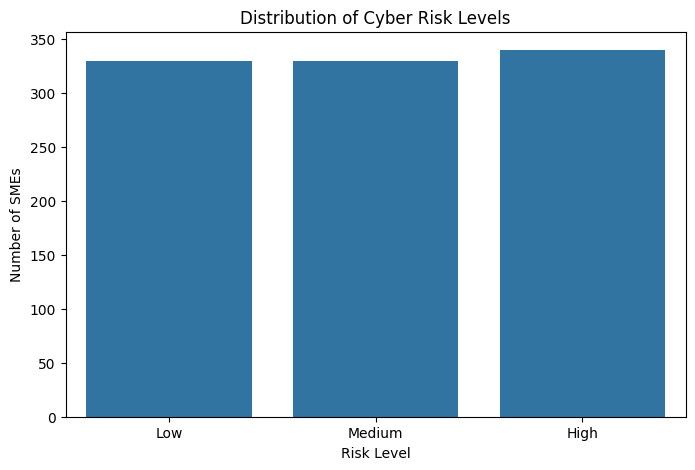

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Risk_Level",
    data=df,
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Cyber Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of SMEs")
# Save figure
plt.savefig(
    "/Users/prakashpanta/Desktop/Cyber_Security_Risk_Assessment/Outputs/Figures/risk_level_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()